In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/content/drive/MyDrive/My Work/spam.csv",encoding='latin1')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [5]:
df = df.drop(["Unnamed: 2","Unnamed: 3","Unnamed: 4"],axis=1)

In [6]:
df = df.rename(columns = {"v1":"Target","v2":"Email"})

In [7]:
from sklearn.preprocessing import LabelEncoder
labelEncoder = LabelEncoder()

In [8]:
df["Target"] = labelEncoder.fit_transform(df["Target"])

In [9]:
df.isnull().sum()

,0
Target,0
Email,0


In [10]:
df.duplicated().sum()

np.int64(403)

In [11]:
df = df.drop_duplicates()

EDA

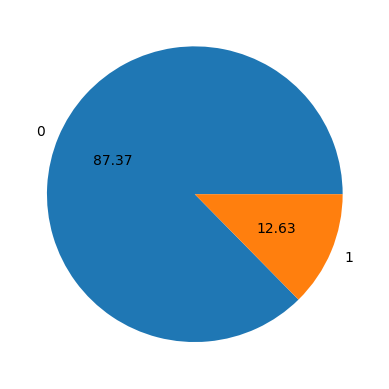

In [12]:
plt.pie(df["Target"].value_counts(),labels=[0,1],autopct="%0.2f")
plt.show()


In [13]:
import nltk

In [14]:
nltk.download("punkt")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [15]:
df['Letter_Len'] = df["Email"].apply(len)

In [16]:
df["Words_Count"] = df["Email"].apply(lambda x: len(nltk.word_tokenize(x)))

In [17]:
df["Sent_Count"] = df["Email"].apply(lambda x: len(nltk.sent_tokenize(x)))

In [18]:
df[df["Target"] == 0]["Letter_Len"]

,Letter_Len
0,111
1,29
3,49
4,61
6,77
...,...
5565,12
5568,37
5569,57
5570,125


<Axes: xlabel='Letter_Len', ylabel='Count'>

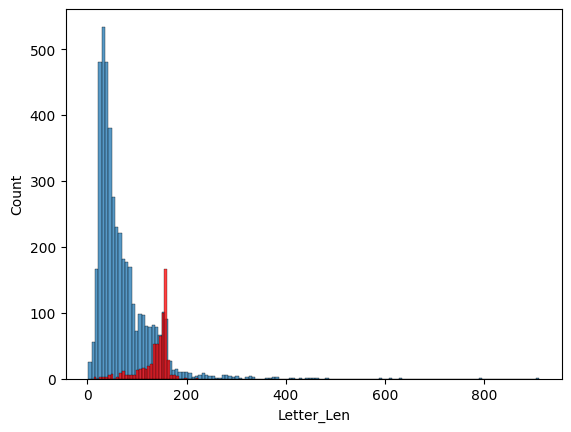

In [19]:
sns.histplot(df[df["Target"] == 0]["Letter_Len"])
sns.histplot(df[df["Target"] == 1]["Letter_Len"],color="red")

<Axes: xlabel='Words_Count', ylabel='Count'>

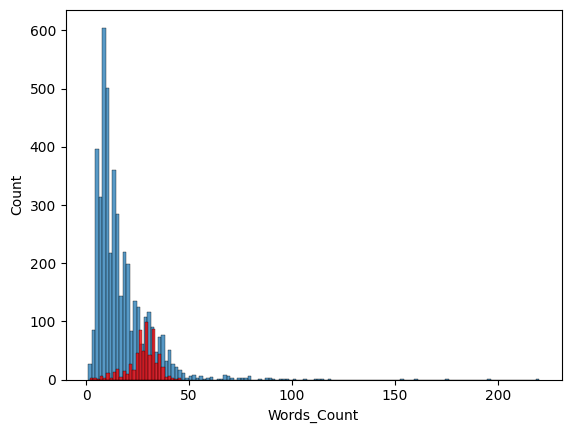

In [20]:
sns.histplot(df[df["Target"] == 0]["Words_Count"])
sns.histplot(df[df["Target"] == 1]["Words_Count"],color="red")

<Axes: xlabel='Sent_Count', ylabel='Count'>

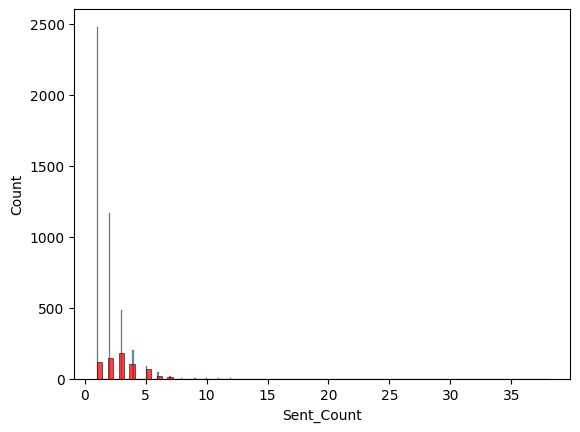

In [21]:
sns.histplot(df[df["Target"] == 0]["Sent_Count"])
sns.histplot(df[df["Target"] == 1]["Sent_Count"],color="red")

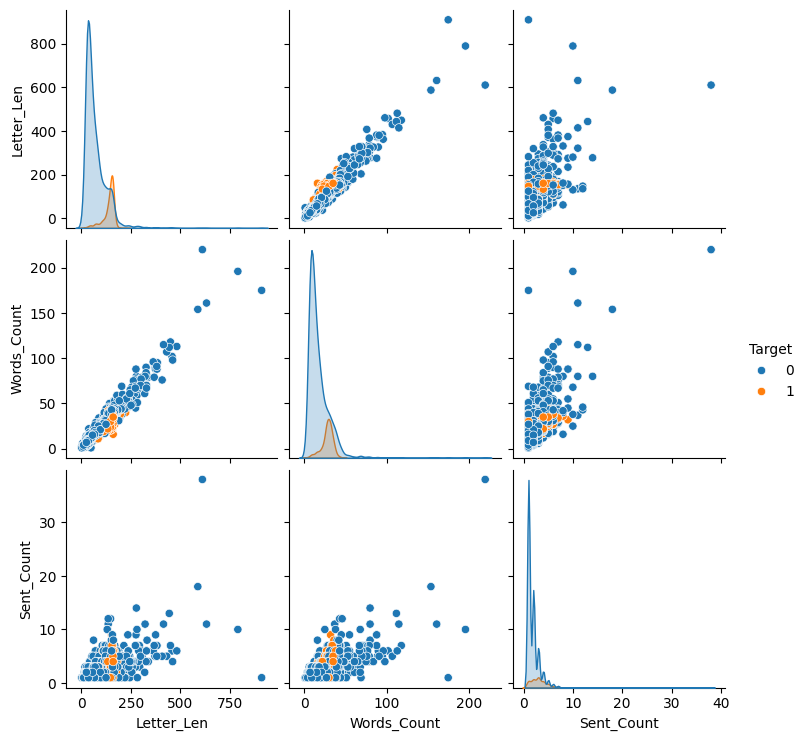

In [22]:
sns.pairplot(df,hue="Target")

<Axes: >

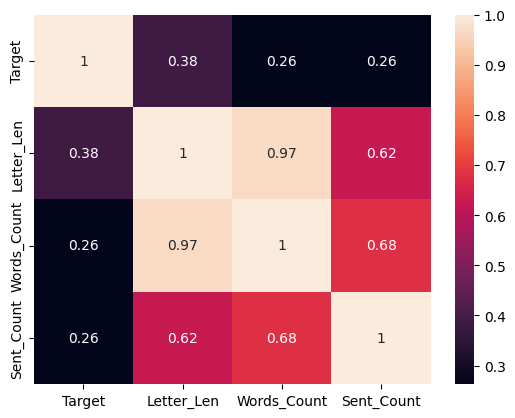

In [23]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [24]:
from nltk.corpus import stopwords
import string
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [25]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [26]:
def testModify(x):
  x = x.lower()
  x = nltk.word_tokenize(x)
  y = []
  for i in x:
    if i.isalnum():
      y.append(i)
  x = y.copy()
  y.clear()
  y = []
  for i in x:
    if i not in stopwords.words("english") and i not in string.punctuation:
        y.append(i)
  x = y.copy()
  y.clear()
  for i in x:
    y.append(ps.stem(i))
  return " ".join(y)

In [27]:
df["Transtion_Text"] = df["Email"].apply(testModify)

In [28]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color="white")

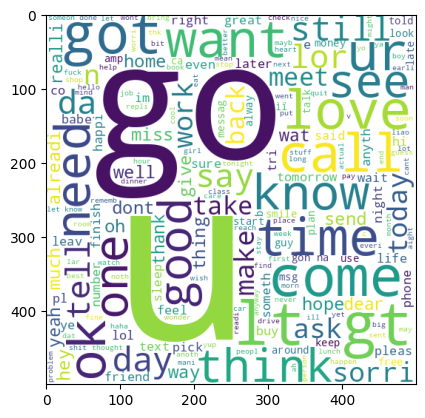

In [29]:
wc.generate (df[df['Target'] == 0]["Transtion_Text"].str.cat(sep=" "))
plt.imshow(wc)

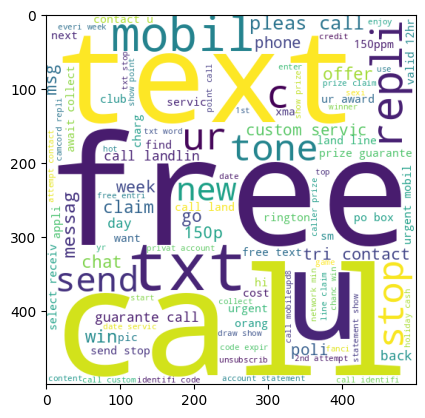

In [30]:
wc.generate (df[df['Target'] == 1]["Transtion_Text"].str.cat(sep=" "))
plt.imshow(wc)

In [31]:
def convertToList(x):
  txnotspam = []
  for i in text:
      for j in i.split():
        txnotspam.append(j)
  return txnotspam

In [32]:
from collections import Counter

In [33]:
text = df[df["Target"] == 0]["Transtion_Text"].tolist()
nottx = convertToList(text)

In [34]:
nottx = Counter(nottx).most_common(30)

In [35]:
nottx_df = pd.DataFrame(nottx, columns=["Word", "Count"])

<Axes: xlabel='Count', ylabel='Word'>

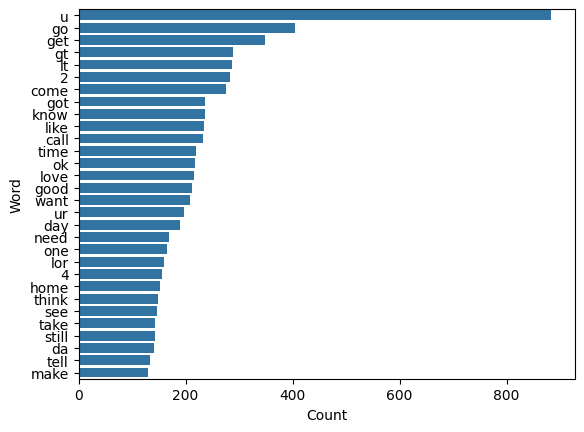

In [36]:
sns.barplot(data=nottx_df, x="Count", y="Word")

In [37]:
text = df[df["Target"] == 1]["Transtion_Text"].tolist()
spamtx = convertToList(text)

In [38]:
spamtx = Counter(spamtx).most_common(30)

In [39]:
spamtx_df = pd.DataFrame(spamtx, columns=["Word", "Count"])

<Axes: xlabel='Count', ylabel='Word'>

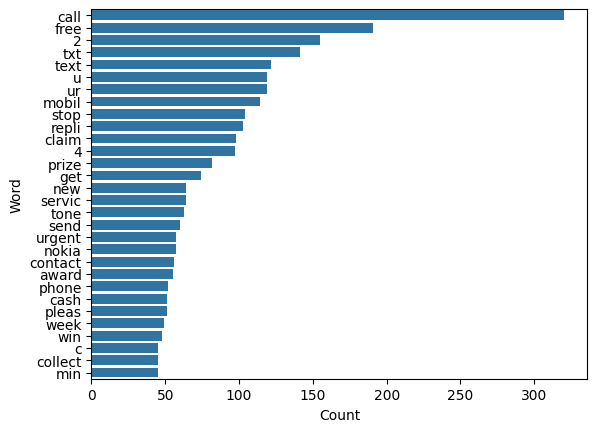

In [40]:
sns.barplot(data=spamtx_df, x="Count", y="Word")

Models


In [41]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
# cv = CountVectorizer()
tfd = TfidfVectorizer()

In [42]:
X = tfd.fit_transform(df["Transtion_Text"]).toarray()

In [43]:
# from sklearn.preprocessing import MinMaxScaler
# scale = MinMaxScaler()

In [44]:
# X = scale.fit_transform(X)

In [45]:
y = df["Target"].values

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train,X_test,Y_train,Y_test = train_test_split(X,y,random_state=2,test_size=0.2)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [49]:
LR = LogisticRegression(random_state=42)
GNB = GaussianNB()
MNB = MultinomialNB()
BNB = BernoulliNB()
DTC = DecisionTreeClassifier(random_state=42,max_depth=6)
RFC = RandomForestClassifier(random_state=42,n_estimators=50)
ETC = ExtraTreesClassifier(random_state=42,n_estimators=50)
GBC = GradientBoostingClassifier(random_state=42,n_estimators=50)
BC = BaggingClassifier(random_state=42,n_estimators=50)
ABC = AdaBoostClassifier(random_state=42,n_estimators=50)
SVCM = SVC(random_state=42,kernel="sigmoid")
KNC = KNeighborsClassifier()
MLPC = MLPClassifier(random_state=42)
XGBC = XGBClassifier(random_state=42,n_estimators=50)
LGBMC = LGBMClassifier(random_state=42,n_estimators=50)

In [61]:
models = {
    # "LR": LR,
    # "GNB": GNB,
    # "MNB": MNB,
    # "BNB": BNB,
    # "DTC": DTC,
    # "RFC": RFC,
    # "ETC": ETC,
    # "GBC": GBC,
    # "BC": BC,
    # "ABC": ABC,
    "KNC": KNC,
    "MLPC": MLPC,
    "XGBC": XGBC,
    "LGBMC": LGBMC
}

In [51]:
from sklearn.ensemble import VotingClassifier
vc = VotingClassifier(estimators=[("MNB",MNB),("SVCM",SVC),("KNC",KNC)],voting="soft")

In [52]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

lr = LogisticRegression(max_iter=1000)
nb = MultinomialNB()
svc = SVC(probability=True)

vc = VotingClassifier(
    estimators=[
        ("lr", lr),
        ("nb", nb),
        ("svc", svc)
    ],
    voting="soft"
)

vc.fit(X_train, Y_train)

y_pred = vc.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report,roc_auc_score

In [56]:
accuracy = accuracy_score(Y_test, y_pred)
accuracy

0.971953578336557

In [57]:
precision = precision_score(Y_test, y_pred)
precision

0.9739130434782609

In [ ]:
# from sklearn.ensemble import StackingClassifier
# estimators = [
#     ('rf', RandomForestClassifier(random_state=42)),
#     ('dt', DecisionTreeClassifier(random_state=42)),
#     ('knn', KNeighborsClassifier()),
#     ('SVCM', SVC(probability=True, random_state=42))
# ]
# stack = StackingClassifier(
#     estimators=estimators,
#     final_estimator=LogisticRegression(),
#     cv=5
# )
# stack.fit(X_train, Y_train)
# y_pred = vc.predict(X_test)
# accuracy = accuracy_score(Y_test, y_pred)
# precision = precision_score(Y_test, y_pred)

In [58]:
def trainClassifier(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [62]:
accuracy_scores = []
precision_scores = []

for name, model in models.items():
    curr_accuracy, curr_precision = trainClassifier(
        model,
        X_train,
        Y_train,
        X_test,
        Y_test
    )
    print(name,"curr_accuracy",curr_accuracy,curr_precision)

    accuracy_scores.append(curr_accuracy)
    precision_scores.append(curr_precision)

KNC curr_accuracy 0.9003868471953579 1.0
MLPC curr_accuracy 0.97678916827853 0.9672131147540983
XGBC curr_accuracy 0.9709864603481625 0.9426229508196722
[LightGBM] [Info] Number of positive: 515, number of negative: 3620
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6430
[LightGBM] [Info] Number of data points in the train set: 4135, number of used features: 338
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.124547 -> initscore=-1.950062
[LightGBM] [Info] Start training from score -1.950062
LGBMC curr_accuracy 0.9700193423597679 0.9147286821705426


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
perform = {
    "Model": list(models.keys()),
    "Accuracy": accuracy_scores,
    "Precision": precision_scores
}
performance_model = pd.DataFrame(perform)

In [67]:
MNB.fit(X_train, Y_train)
y_pred = MNB.predict(X_test)

accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)


y_prob = MNB.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(Y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9825593620600414


In [69]:
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("Precision:", precision_score(Y_test, y_pred))
print("Recall:", recall_score(Y_test, y_pred))
print("F1 Score:", f1_score(Y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(Y_test, y_prob))

Accuracy: 0.9593810444874274
Precision: 1.0
Recall: 0.6956521739130435
F1 Score: 0.8205128205128205
Confusion Matrix:
[[896   0]
 [ 42  96]]
ROC-AUC  : 0.9825593620600414


In [71]:
import pickle

pickle.dump(testModify, open("testModifyFunction.pkl", "wb"))
pickle.dump(tfd, open("tfidfvectorizer.pkl", "wb"))
pickle.dump(MNB, open("MultinomialNBModel.pkl", "wb"))

In [ ]:
# Accuracy: 0.9593810444874274
# Precision: 1.0
# Recall: 0.6956521739130435
# F1 Score: 0.8205128205128205
# Confusion Matrix:
# [[896   0]
#  [ 42  96]]
# ROC-AUC  : 0.9825593620600414
